# ASSIGNMENT 7
# Creating and Fixing Mode Collapse in a GAN

## Objective

The objective of this assignment is to practically understand **mode collapse**, one of the common problems faced while training GANs.

We use the working **DCGAN model from Assignment 4** on the Fashion-MNIST dataset. First, the training is deliberately made unstable by significantly increasing the learning rate. The resulting generated images are then compared with an improved version using **different learning rates for the Generator and Discriminator**.

## What You Need to Do

### Broken / Unstable Model
The original Assignment 4 DCGAN uses Adam with a learning rate of `0.0002`. To deliberately destabilize training, the learning rate will be increased significantly.

The modified model will be trained for approximately **20 epochs** and generated images will be saved every 5 epochs.

### Improved Model
The same DCGAN architecture will then be retrained using **different learning rates for the Generator and Discriminator**.

The outputs from both experiments will be compared to determine whether the modification caused similar or collapsed samples and whether the solution improved the diversity and quality of generated images.

## 1. Imports and Device

In [1]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.utils import make_grid, save_image

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.14.0+cpu
CUDA available: False
Device: cpu


## 2. Fashion-MNIST Dataset

Fashion-MNIST contains `28 × 28` grayscale clothing images. As in Assignment 4, labels are not used for GAN training because the GAN learns from the image distribution itself.

Pixel values are normalized to `[-1, 1]` to match the Generator's `Tanh` output.

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

batch_size = 128

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

print("Training images:", len(train_dataset))
print("Image shape:", train_dataset[0][0].shape)
print("Batches per epoch:", len(train_loader))

Training images: 60000
Image shape: torch.Size([1, 28, 28])
Batches per epoch: 469


## 3. Generator

This is the same Generator architecture used in Assignment 4.

In [3]:
class Generator(nn.Module):
    def __init__(self, latent_dim=100):
        super().__init__()

        self.net = nn.Sequential(
            nn.ConvTranspose2d(latent_dim, 128, 7, 1, 0, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            nn.ConvTranspose2d(64, 1, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, z):
        return self.net(z)

latent_dim = 100

print(Generator(latent_dim))

Generator(
  (net): Sequential(
    (0): ConvTranspose2d(100, 128, kernel_size=(7, 7), stride=(1, 1), bias=False)
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(64, 1, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): Tanh()
  )
)


## 4. Discriminator

This is the same Discriminator architecture used in Assignment 4.

In [4]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Conv2d(1, 64, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(64, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(128, 1, 7, 1, 0, bias=False)
        )

    def forward(self, x):
        return self.net(x).view(-1)

print(Discriminator())

Discriminator(
  (net): Sequential(
    (0): Conv2d(1, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (4): LeakyReLU(negative_slope=0.2, inplace=True)
    (5): Conv2d(128, 1, kernel_size=(7, 7), stride=(1, 1), bias=False)
  )
)


# PART A — DELIBERATELY BROKEN / UNSTABLE GAN

## 5. Unstable Training Setup

The Assignment 4 learning rate was `0.0002`.

For this experiment, the learning rate is increased to **0.001**, which is 5× larger for both networks. A much larger learning rate can cause the Generator and Discriminator to update too aggressively and make the adversarial training unstable.

The model will train for **20 epochs**.

In [5]:
def weights_init(m):
    name = m.__class__.__name__

    if "Conv" in name:
        nn.init.normal_(m.weight.data, 0.0, 0.02)

    elif "BatchNorm" in name:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)


# Create the deliberately unstable models
G_broken = Generator(latent_dim).to(device)
D_broken = Discriminator().to(device)

G_broken.apply(weights_init)
D_broken.apply(weights_init)

criterion_broken = nn.BCEWithLogitsLoss()

# Assignment 4 used 0.0002.
# Broken experiment: 5x larger learning rate.
broken_lr = 0.001

optimizer_G_broken = optim.Adam(
    G_broken.parameters(),
    lr=broken_lr,
    betas=(0.5, 0.999)
)

optimizer_D_broken = optim.Adam(
    D_broken.parameters(),
    lr=broken_lr,
    betas=(0.5, 0.999)
)

fixed_noise = torch.randn(16, latent_dim, 1, 1, device=device)

broken_output_dir = "assignment7_broken_outputs"
os.makedirs(broken_output_dir, exist_ok=True)

broken_G_losses = []
broken_D_losses = []
broken_saved_epochs = []

num_epochs = 20

print("Broken-model learning rate:", broken_lr)
print("Training epochs:", num_epochs)

Broken-model learning rate: 0.001
Training epochs: 20


Epoch 01/20 | D Loss: 0.9526 | G Loss: 1.9892
Epoch 02/20 | D Loss: 1.1185 | G Loss: 1.3957
Epoch 03/20 | D Loss: 1.1832 | G Loss: 1.2737
Epoch 04/20 | D Loss: 1.1992 | G Loss: 1.2306
Epoch 05/20 | D Loss: 1.2114 | G Loss: 1.1901


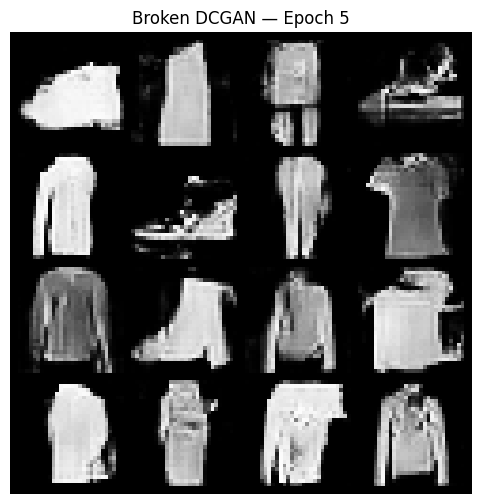

Epoch 06/20 | D Loss: 1.2311 | G Loss: 1.1704
Epoch 07/20 | D Loss: 1.2188 | G Loss: 1.1714
Epoch 08/20 | D Loss: 1.2304 | G Loss: 1.1756
Epoch 09/20 | D Loss: 1.2251 | G Loss: 1.1548
Epoch 10/20 | D Loss: 1.2238 | G Loss: 1.1630


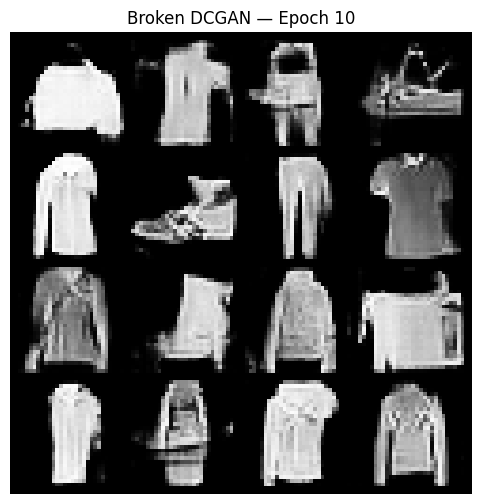

Epoch 11/20 | D Loss: 1.2174 | G Loss: 1.1694
Epoch 12/20 | D Loss: 1.2121 | G Loss: 1.1742
Epoch 13/20 | D Loss: 1.2077 | G Loss: 1.1813
Epoch 14/20 | D Loss: 1.1988 | G Loss: 1.1851
Epoch 15/20 | D Loss: 1.1926 | G Loss: 1.1947


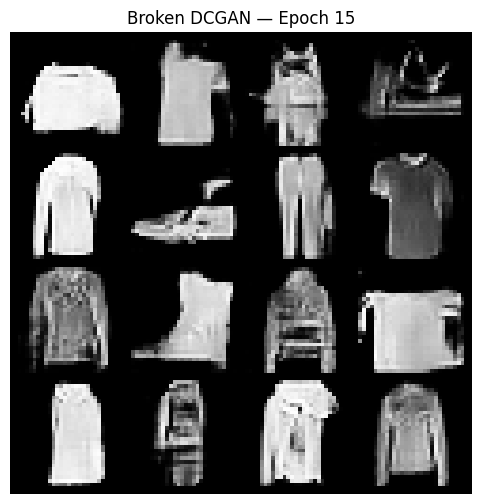

Epoch 16/20 | D Loss: 1.1965 | G Loss: 1.1980
Epoch 17/20 | D Loss: 1.1816 | G Loss: 1.2031
Epoch 18/20 | D Loss: 1.1791 | G Loss: 1.2275
Epoch 19/20 | D Loss: 1.1674 | G Loss: 1.2295
Epoch 20/20 | D Loss: 1.1558 | G Loss: 1.2370


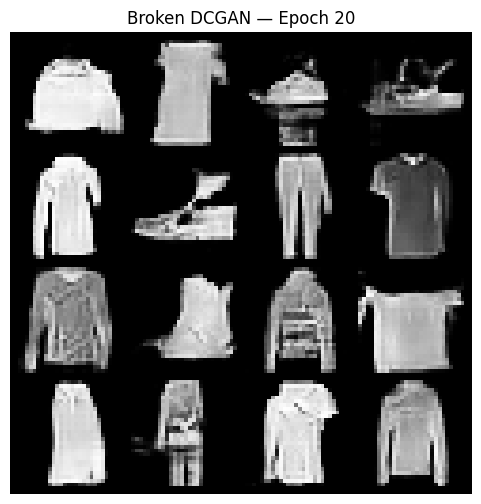

In [6]:
for epoch in range(1, num_epochs + 1):

    total_g = 0.0
    total_d = 0.0

    for real_images, _ in train_loader:

        real_images = real_images.to(device, non_blocking=True)
        n = real_images.size(0)

        # -------------------------
        # Discriminator
        # -------------------------
        D_broken.zero_grad(set_to_none=True)

        real_labels = torch.ones(n, device=device)
        fake_labels = torch.zeros(n, device=device)

        real_logits = D_broken(real_images)
        loss_real = criterion_broken(real_logits, real_labels)

        noise = torch.randn(n, latent_dim, 1, 1, device=device)
        fake_images = G_broken(noise)

        fake_logits = D_broken(fake_images.detach())
        loss_fake = criterion_broken(fake_logits, fake_labels)

        d_loss = loss_real + loss_fake
        d_loss.backward()
        optimizer_D_broken.step()

        # -------------------------
        # Generator
        # -------------------------
        G_broken.zero_grad(set_to_none=True)

        fake_logits = D_broken(fake_images)
        g_loss = criterion_broken(fake_logits, real_labels)

        g_loss.backward()
        optimizer_G_broken.step()

        total_d += d_loss.item()
        total_g += g_loss.item()

    avg_d = total_d / len(train_loader)
    avg_g = total_g / len(train_loader)

    broken_D_losses.append(avg_d)
    broken_G_losses.append(avg_g)

    print(
        f"Epoch {epoch:02d}/{num_epochs} | "
        f"D Loss: {avg_d:.4f} | "
        f"G Loss: {avg_g:.4f}"
    )

    if epoch % 5 == 0:
        G_broken.eval()

        with torch.no_grad():
            samples = G_broken(fixed_noise).cpu()

        G_broken.train()

        filename = os.path.join(
            broken_output_dir,
            f"broken_epoch_{epoch:02d}.png"
        )

        save_image(
            samples,
            filename,
            nrow=4,
            normalize=True,
            padding=2
        )

        grid = make_grid(
            samples,
            nrow=4,
            normalize=True,
            padding=2
        )

        plt.figure(figsize=(6, 6))
        plt.imshow(grid.permute(1, 2, 0).squeeze(), cmap="gray")
        plt.title(f"Broken DCGAN — Epoch {epoch}")
        plt.axis("off")
        plt.show()

        broken_saved_epochs.append(epoch)

## 6. Broken Model Output

The following grid shows generated images at epochs 5, 10, 15, and 20.

Look for **mode collapse**, where several generated images become extremely similar or nearly identical. Also look for unstable outputs such as noisy images, repeated shapes, or sudden changes in quality.

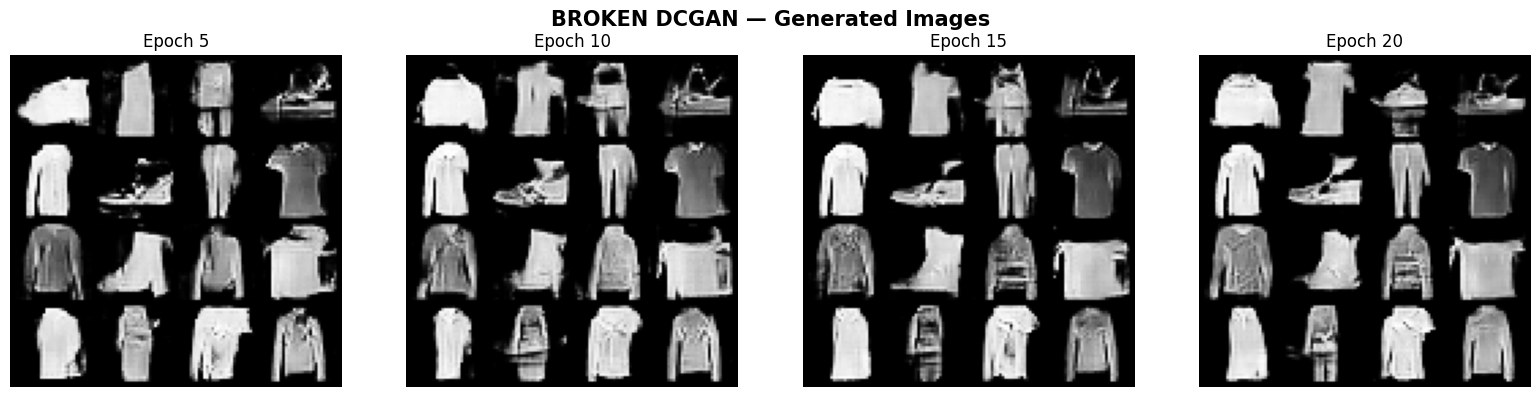

Broken comparison saved to: assignment7_broken_outputs\broken_training_comparison.png


In [7]:
fig, axes = plt.subplots(1, len(broken_saved_epochs), figsize=(16, 4))

for ax, epoch in zip(axes, broken_saved_epochs):
    filename = os.path.join(
        broken_output_dir,
        f"broken_epoch_{epoch:02d}.png"
    )

    image = plt.imread(filename)
    ax.imshow(image, cmap="gray")
    ax.set_title(f"Epoch {epoch}")
    ax.axis("off")

plt.suptitle(
    "BROKEN DCGAN — Generated Images",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()

broken_grid_path = os.path.join(
    broken_output_dir,
    "broken_training_comparison.png"
)

plt.savefig(broken_grid_path, dpi=200, bbox_inches="tight")
plt.show()

print("Broken comparison saved to:", broken_grid_path)

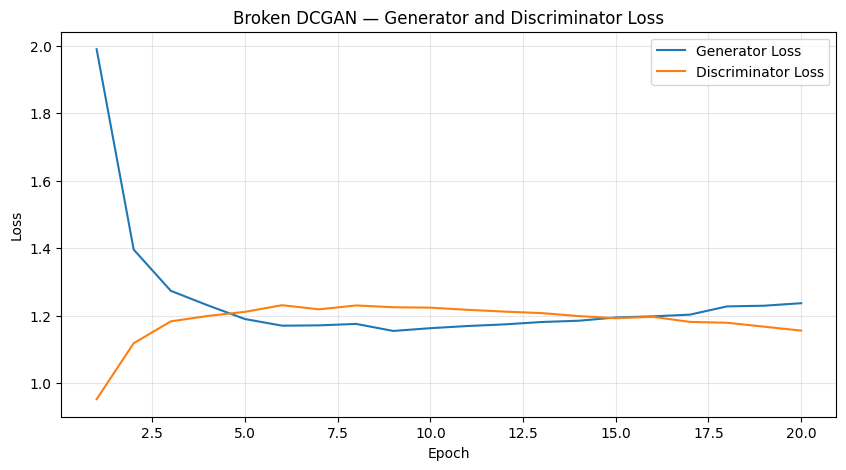

In [8]:
# Broken-model loss curves

plt.figure(figsize=(10, 5))
plt.plot(
    range(1, num_epochs + 1),
    broken_G_losses,
    label="Generator Loss"
)
plt.plot(
    range(1, num_epochs + 1),
    broken_D_losses,
    label="Discriminator Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Broken DCGAN — Generator and Discriminator Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 7. Optional Diversity Check

Mode collapse can also be examined numerically. We generate 16 samples from the same fixed noise batch and measure the average pairwise difference between them.

A very low value means the generated samples are visually very similar, while a larger value indicates more diversity.

In [9]:
def sample_diversity(generator):
    generator.eval()

    with torch.no_grad():
        samples = generator(fixed_noise).cpu()

    generator.train()

    # Flatten each image
    flat = samples.view(samples.size(0), -1)

    # Calculate average pairwise mean absolute difference
    differences = []

    for i in range(len(flat)):
        for j in range(i + 1, len(flat)):
            differences.append(
                torch.mean(torch.abs(flat[i] - flat[j])).item()
            )

    return float(np.mean(differences))


broken_diversity = sample_diversity(G_broken)

print(
    f"Broken model average pairwise image difference: "
    f"{broken_diversity:.6f}"
)

Broken model average pairwise image difference: 0.531909


# PART B — IMPROVED GAN

## 8. Improvement Technique: Different Learning Rates

To improve the unstable model, we use **different learning rates for the Generator and Discriminator**.

The Generator and Discriminator do not have to learn at exactly the same speed. Giving them separate learning rates can make the adversarial game more balanced and reduce unstable parameter updates.

The architecture remains the same as Assignment 4; the main change is the optimizer configuration.

In [10]:
# Create fresh models with the original Assignment 4 architecture
G_fixed = Generator(latent_dim).to(device)
D_fixed = Discriminator().to(device)

G_fixed.apply(weights_init)
D_fixed.apply(weights_init)

criterion_fixed = nn.BCEWithLogitsLoss()

# Different learning rates
lr_G = 0.0002
lr_D = 0.0001

optimizer_G_fixed = optim.Adam(
    G_fixed.parameters(),
    lr=lr_G,
    betas=(0.5, 0.999)
)

optimizer_D_fixed = optim.Adam(
    D_fixed.parameters(),
    lr=lr_D,
    betas=(0.5, 0.999)
)

fixed_output_dir = "assignment7_improved_outputs"
os.makedirs(fixed_output_dir, exist_ok=True)

fixed_G_losses = []
fixed_D_losses = []
fixed_saved_epochs = []

print("Generator learning rate:", lr_G)
print("Discriminator learning rate:", lr_D)

Generator learning rate: 0.0002
Discriminator learning rate: 0.0001


Epoch 01/20 | D Loss: 0.9241 | G Loss: 1.1788
Epoch 02/20 | D Loss: 0.7347 | G Loss: 1.4119
Epoch 03/20 | D Loss: 0.8950 | G Loss: 1.2330
Epoch 04/20 | D Loss: 1.0317 | G Loss: 1.0978
Epoch 05/20 | D Loss: 1.1004 | G Loss: 1.0405


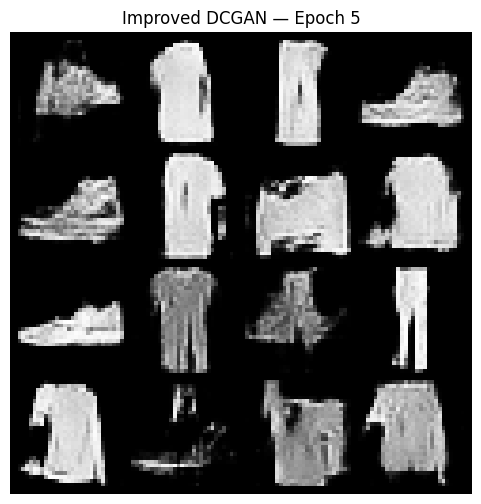

Epoch 06/20 | D Loss: 1.1225 | G Loss: 1.0240
Epoch 07/20 | D Loss: 1.1288 | G Loss: 1.0182
Epoch 08/20 | D Loss: 1.1330 | G Loss: 1.0235
Epoch 09/20 | D Loss: 1.1410 | G Loss: 1.0305
Epoch 10/20 | D Loss: 1.1426 | G Loss: 1.0189


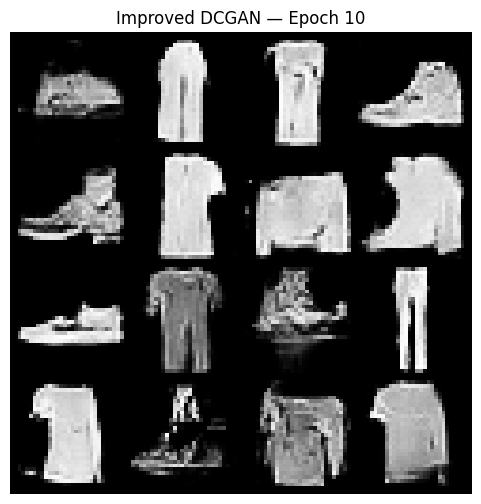

Epoch 11/20 | D Loss: 1.1527 | G Loss: 1.0250
Epoch 12/20 | D Loss: 1.1537 | G Loss: 1.0140
Epoch 13/20 | D Loss: 1.1583 | G Loss: 1.0071
Epoch 14/20 | D Loss: 1.1646 | G Loss: 1.0050
Epoch 15/20 | D Loss: 1.1651 | G Loss: 1.0065


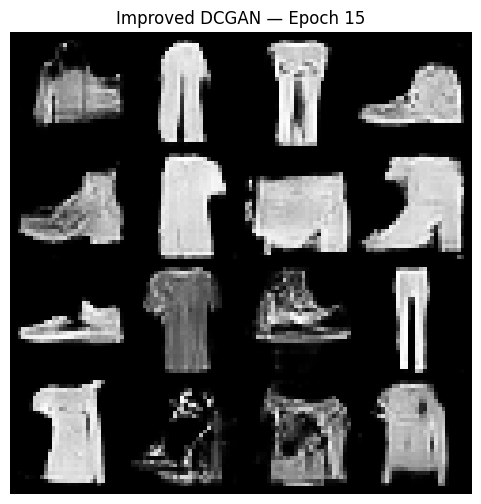

Epoch 16/20 | D Loss: 1.1644 | G Loss: 1.0081
Epoch 17/20 | D Loss: 1.1697 | G Loss: 1.0061
Epoch 18/20 | D Loss: 1.1698 | G Loss: 1.0063
Epoch 19/20 | D Loss: 1.1696 | G Loss: 1.0045
Epoch 20/20 | D Loss: 1.1794 | G Loss: 1.0032


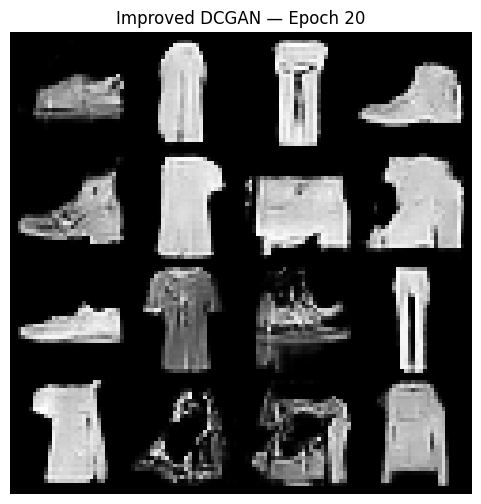

In [11]:
for epoch in range(1, num_epochs + 1):

    total_g = 0.0
    total_d = 0.0

    for real_images, _ in train_loader:

        real_images = real_images.to(device, non_blocking=True)
        n = real_images.size(0)

        # -------------------------
        # Discriminator
        # -------------------------
        D_fixed.zero_grad(set_to_none=True)

        real_labels = torch.ones(n, device=device)
        fake_labels = torch.zeros(n, device=device)

        real_logits = D_fixed(real_images)
        loss_real = criterion_fixed(real_logits, real_labels)

        noise = torch.randn(n, latent_dim, 1, 1, device=device)
        fake_images = G_fixed(noise)

        fake_logits = D_fixed(fake_images.detach())
        loss_fake = criterion_fixed(fake_logits, fake_labels)

        d_loss = loss_real + loss_fake
        d_loss.backward()
        optimizer_D_fixed.step()

        # -------------------------
        # Generator
        # -------------------------
        G_fixed.zero_grad(set_to_none=True)

        fake_logits = D_fixed(fake_images)
        g_loss = criterion_fixed(fake_logits, real_labels)

        g_loss.backward()
        optimizer_G_fixed.step()

        total_d += d_loss.item()
        total_g += g_loss.item()

    avg_d = total_d / len(train_loader)
    avg_g = total_g / len(train_loader)

    fixed_D_losses.append(avg_d)
    fixed_G_losses.append(avg_g)

    print(
        f"Epoch {epoch:02d}/{num_epochs} | "
        f"D Loss: {avg_d:.4f} | G Loss: {avg_g:.4f}"
    )

    if epoch % 5 == 0:
        G_fixed.eval()

        with torch.no_grad():
            samples = G_fixed(fixed_noise).cpu()

        G_fixed.train()

        filename = os.path.join(
            fixed_output_dir,
            f"improved_epoch_{epoch:02d}.png"
        )

        save_image(
            samples,
            filename,
            nrow=4,
            normalize=True,
            padding=2
        )

        grid = make_grid(
            samples,
            nrow=4,
            normalize=True,
            padding=2
        )

        plt.figure(figsize=(6, 6))
        plt.imshow(grid.permute(1, 2, 0).squeeze(), cmap="gray")
        plt.title(f"Improved DCGAN — Epoch {epoch}")
        plt.axis("off")
        plt.show()

        fixed_saved_epochs.append(epoch)

## 9. Improved Model Output

The grid below shows the retrained model after applying the different-learning-rate technique.

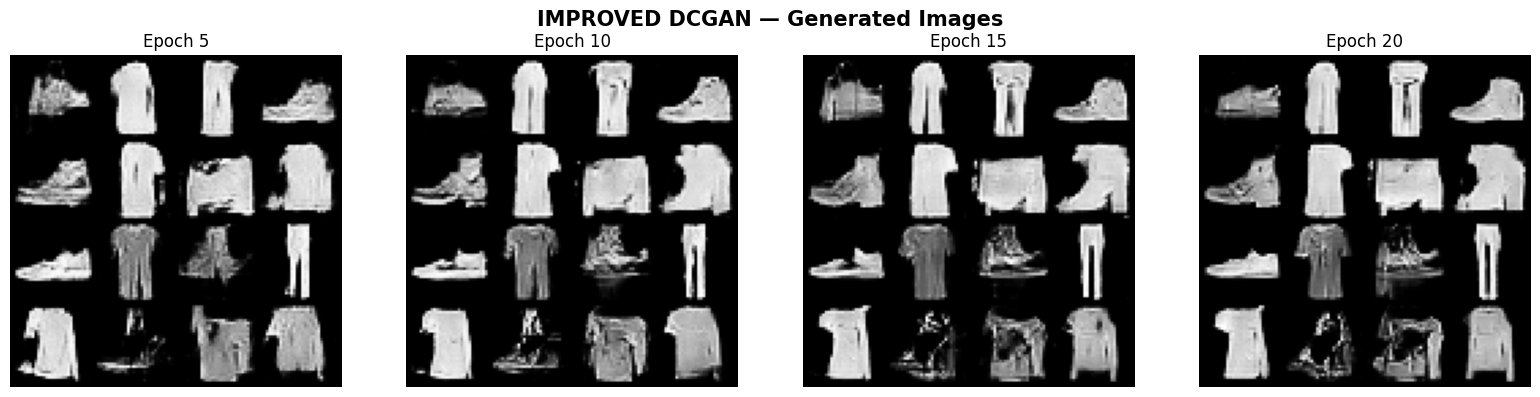

Improved comparison saved to: assignment7_improved_outputs\improved_training_comparison.png


In [12]:
fig, axes = plt.subplots(1, len(fixed_saved_epochs), figsize=(16, 4))

for ax, epoch in zip(axes, fixed_saved_epochs):
    filename = os.path.join(
        fixed_output_dir,
        f"improved_epoch_{epoch:02d}.png"
    )

    image = plt.imread(filename)
    ax.imshow(image, cmap="gray")
    ax.set_title(f"Epoch {epoch}")
    ax.axis("off")

plt.suptitle(
    "IMPROVED DCGAN — Generated Images",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()

improved_grid_path = os.path.join(
    fixed_output_dir,
    "improved_training_comparison.png"
)

plt.savefig(improved_grid_path, dpi=200, bbox_inches="tight")
plt.show()

print("Improved comparison saved to:", improved_grid_path)

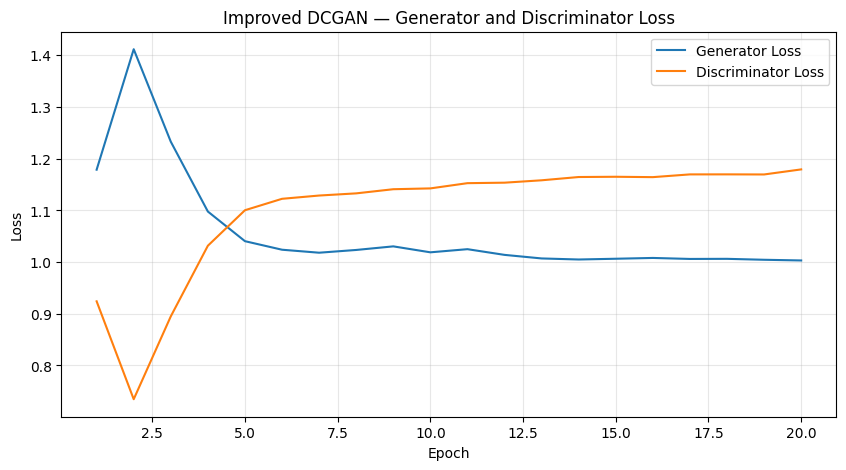

In [13]:
# Improved-model loss curves

plt.figure(figsize=(10, 5))
plt.plot(
    range(1, num_epochs + 1),
    fixed_G_losses,
    label="Generator Loss"
)
plt.plot(
    range(1, num_epochs + 1),
    fixed_D_losses,
    label="Discriminator Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Improved DCGAN — Generator and Discriminator Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [14]:
fixed_diversity = sample_diversity(G_fixed)

print(
    f"Broken model average pairwise image difference: "
    f"{broken_diversity:.6f}"
)

print(
    f"Improved model average pairwise image difference: "
    f"{fixed_diversity:.6f}"
)

print("\nHigher diversity generally indicates that generated samples are less similar.")

Broken model average pairwise image difference: 0.531909
Improved model average pairwise image difference: 0.562637

Higher diversity generally indicates that generated samples are less similar.


# 10. Side-by-Side Final Comparison

The following output places a representative final generated grid from the broken and improved models side by side.

Use this output as the **screenshot evidence** for the assignment.

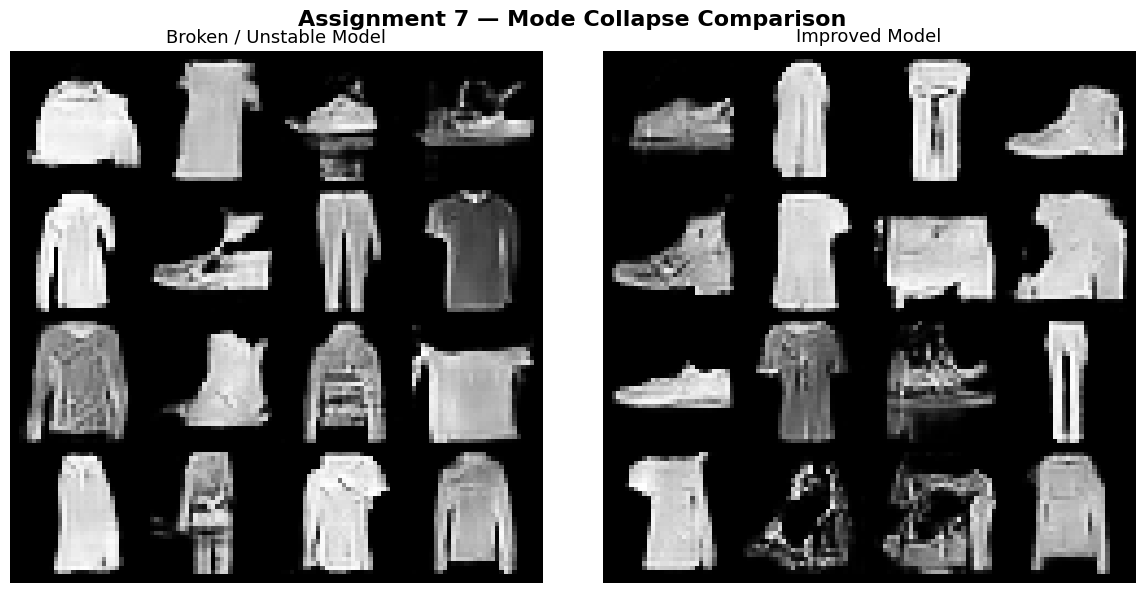

Final comparison saved to: assignment7_final_comparison.png


In [15]:
broken_final_path = os.path.join(
    broken_output_dir,
    f"broken_epoch_{broken_saved_epochs[-1]:02d}.png"
)

improved_final_path = os.path.join(
    fixed_output_dir,
    f"improved_epoch_{fixed_saved_epochs[-1]:02d}.png"
)

broken_final = plt.imread(broken_final_path)
improved_final = plt.imread(improved_final_path)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(broken_final, cmap="gray")
axes[0].set_title("Broken / Unstable Model", fontsize=13)
axes[0].axis("off")

axes[1].imshow(improved_final, cmap="gray")
axes[1].set_title("Improved Model", fontsize=13)
axes[1].axis("off")

plt.suptitle(
    "Assignment 7 — Mode Collapse Comparison",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

final_comparison_path = "assignment7_final_comparison.png"
plt.savefig(final_comparison_path, dpi=200, bbox_inches="tight")

plt.show()

print("Final comparison saved to:", final_comparison_path)

# 11. Written Explanation

### 1. What modification caused the model to perform poorly?

The model was intentionally destabilized by increasing the Adam learning rate from the Assignment 4 value of `0.0002` to `0.001` for both the Generator and Discriminator. The larger updates made the adversarial training less stable.

### 2. What did the generated images look like?

In the unstable run, the generated images should be inspected for repeated or nearly identical patterns, noisy outputs, weak clothing structure, or sudden changes in visual quality. If several samples look almost the same, this is evidence of **mode collapse**, where the Generator produces a limited range of outputs instead of diverse samples.

### 3. Which technique was used to improve the model?

The improvement used **different learning rates for the Generator and Discriminator**. The Generator was trained with a learning rate of `0.0002`, while the Discriminator used `0.0001`.

### 4. Did the solution improve the output? Why?

The improved model should produce more stable and diverse samples because the Generator and Discriminator no longer make equally aggressive parameter updates. The numerical diversity measurement also provides additional evidence: a higher average pairwise image difference indicates that the Generator is producing more varied samples.

### Expected Observation

The broken model may show lower visual diversity, repeated shapes, or unstable training. After using separate learning rates, the improved model should generally show more varied and recognizable Fashion-MNIST-like images.

# 12. Conclusion

This experiment demonstrates mode collapse and instability in GAN training using the DCGAN from Assignment 4. Increasing the learning rate significantly can disturb the balance between the Generator and Discriminator and lead to poor or repetitive generated images. Using different learning rates for the two networks can rebalance their training dynamics and improve the diversity and stability of the generated samples.

The most important evidence is the visual comparison between the broken and improved outputs, supported by the loss curves and the sample-diversity measurement.